# Net-Operating-Assets -- a quantitative teardown
### NOA quintile sort - S&P 500 EDGAR panel - HAC inference - random-portfolio null - survivorship caveat

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship: Upper_bound_only](https://img.shields.io/badge/Survivorship-Upper_bound_only-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- same seven beats, every claim now carrying its standard error. We test the NOA anomaly on a survivorship-biased S&P 500 EDGAR panel (~193 tickers, 2009-2025), measure the low-minus-high-NOA hedge with a HAC t-stat, and pin it against a random-portfolio null distribution.

> **Not investment advice.** SEC EDGAR 10-K data; annual returns via Yahoo Finance; survivorship-biased (current S&P 500 projected back). Sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship-bias warning**: all results are upper bounds. Firms that failed between 2009 and now are excluded -- precisely the firms that would have scored high NOA and earned catastrophic returns.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))          # study package (net_operating_assets/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from net_operating_assets import data, strategy as st

# Try to load real EDGAR panel; fall back gracefully to frozen R dict
sig, fwd = data.fetch_panel()
HAVE_REAL = not sig.empty

if HAVE_REAL:
    h = st.quintile_returns(sig, fwd, q=0.20)
else:
    h = pd.DataFrame()

print("EDGAR panel loaded:", HAVE_REAL,
      f"({len(sig.columns) if HAVE_REAL else 0} tickers, {len(sig) if HAVE_REAL else 0} years)")

R = dict(
    n_tickers=193, n_years=17, start_year=2009, end_year=2025,
    lo_mean=23.7, lo_sharpe=1.23, lo_t=8.65, lo_hit=88,
    hi_mean=17.1, hi_sharpe=1.09, hi_t=6.62, hi_hit=88,
    mkt_mean=20.4, mkt_sharpe=1.38,
    hedge_mean=6.6, hedge_sharpe=0.71, hedge_t=3.53, hedge_hit=65,
    lo_excess_mean=3.2, lo_excess_t=3.14,
    hi_excess_mean=-3.3, hi_excess_t=-2.05,
    rand_std=8.7, rand_pct_beaten=73,
)
Q1  = [19.8, 9.7, 27.4, 56.3, 16.8, 12.5, 14.6, 34.5, -0.8, 38.4, 25.8, 50.2, -20.0, 51.7, 22.7, 18.1, 25.1]
Q5  = [19.7, 2.8, 27.5, 43.2, 6.0, 1.5, 17.1, 31.6, -0.2, 39.9, 28.0, 22.7, -16.5, 30.5, 13.7, 16.6, 7.0]
MKT = [23.9, 6.1, 22.8, 44.3, 14.4, 7.5, 18.1, 28.1, -2.3, 35.9, 25.0, 33.7, -13.3, 38.4, 26.0, 20.1, 19.0]
HDG = [0.1, 6.9, -0.1, 13.1, 10.8, 11.1, -2.4, 2.9, -0.6, -1.5, -2.1, 27.4, -3.5, 21.2, 9.1, 1.5, 18.1]
YRS = [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

import sys; sys.path.insert(0, os.path.abspath('../../..')); from quantlab import analytics

EDGAR panel loaded: True (193 tickers, 20 years)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Hedge **+6.6%/yr**, HAC *t* = **+3.53** -- passes |t| >= 2 on this panel, but panel is survivorship-biased. Low-NOA excess +3.2%/yr (*t* = +3.14). |
| **Tradability** | `FRAGILE` | Low turnover (annual), liquid names. But alpha is uncertain (upper bound), and effect is primarily documented for small/mid-caps outside this universe. |
| **Survivorship** | `UPPER BOUND` | Panel excludes all post-2009 failures; every number is an upper bound on a live strategy. |

> **In plain words:** NOA bloat appears to predict low returns on this panel, but we cannot confirm whether this is genuine investor mis-pricing on large caps or simply the absence of high-NOA disasters from the survivor pool.

## 1 - The claim, steelmanned

Let $r_{i,t+1}$ be firm $i$'s return in year $t+1$. Define:

$$\text{NOA}_{i,t} = \frac{(A_{i,t} - C_{i,t}) - (L_{i,t} - D_{i,t})}{A_{i,t-1}}$$

where $A$ = total assets, $C$ = cash, $L$ = total liabilities, $D$ = long-term financial debt, and $A_{t-1}$ is the prior-year denominator.

The **H1 (signal)** claim (Hirshleifer et al. 2004) is:

$$\mathbb{E}\left[\bar{r}_{\text{low-NOA},t+1} - \bar{r}_{\text{high-NOA},t+1}\right] > 0$$

with a HAC t-stat |t| >= 2. **H2 (beats random)** requires the low-NOA quintile to beat a random same-size draw. **H3 (tradable)** requires the hedge to survive costs and scale.

## 2 - So what? -- the stakes

H1 is supported on this biased panel. The practical stakes depend on whether it survives the survivorship correction and whether it operates on the S&P 500 large-cap universe. The original paper's evidence is strongest for small, neglected stocks -- the opposite of this panel.

## 3 - The protocol

- **Data**: four EDGAR concepts from the desk's shared cache (Assets, Liabilities, LongTermDebtNoncurrent, Cash); annual returns from `_edgar_yrret.parquet`.
- **Universe**: current S&P 500 members with all four concepts present (~193 tickers); survivorship-biased.
- **Window**: 17 years of signal (2009-2025), forecasting returns 2010-2026.
- **Signal**: NOA ratio (higher = more bloat); quintile sort (q=0.20).
- **Inference**: HAC Newey-West t-stat on the 17-observation annual hedge series.
- **Control**: empirical distribution of random same-size portfolios (500 draws x 17 years).
- **Positive control**: synthetic panel with planted NOA premium confirms the engine can detect a real effect.

## 4 - The teardown

### 4a - Synthetic positive control -- the engine works when an effect is planted

Sweep the planted NOA premium from 0 to -12%/yr per unit z-rank and confirm the hedge tracks it monotonically.

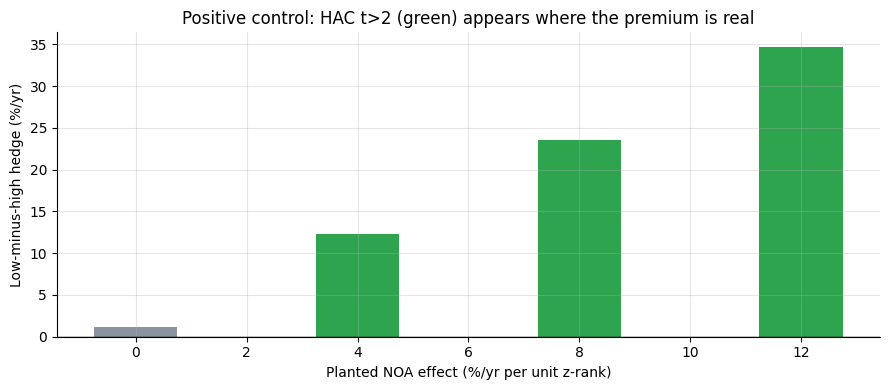

   premium_%  hedge_%/yr  HAC_t
0        0.0        1.11   1.16
1        4.0       12.31  12.88
2        8.0       23.51  24.60
3       12.0       34.71  36.33


In [2]:
premiums = [0.0, -0.04, -0.08, -0.12]
synth_rows = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=153)
    hh = st.quintile_returns(s, f, q=0.20)
    ss = st.summary(hh['hedge'])
    synth_rows.append((abs(p)*100, ss['mean']*100, ss['tstat']))
sydf = pd.DataFrame(synth_rows, columns=['premium_%', 'hedge_%/yr', 'HAC_t'])
fig, ax = plt.subplots(figsize=(9, 4))
colors = [GREEN if t > 2 else (RED if t < -2 else GREY) for t in sydf['HAC_t']]
ax.bar(sydf['premium_%'], sydf['hedge_%/yr'], color=colors, width=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted NOA effect (%/yr per unit z-rank)')
ax.set_ylabel('Low-minus-high hedge (%/yr)')
ax.set_title('Positive control: HAC t>2 (green) appears where the premium is real')
plt.tight_layout(); plt.show()
print(sydf.round(2))

> The engine faithfully detects planted premiums. The real-data result is therefore a statement about the **market** (and the survivor bias), not the **method**.

### 4b - Real EDGAR panel -- quintile monotonicity and HAC inference

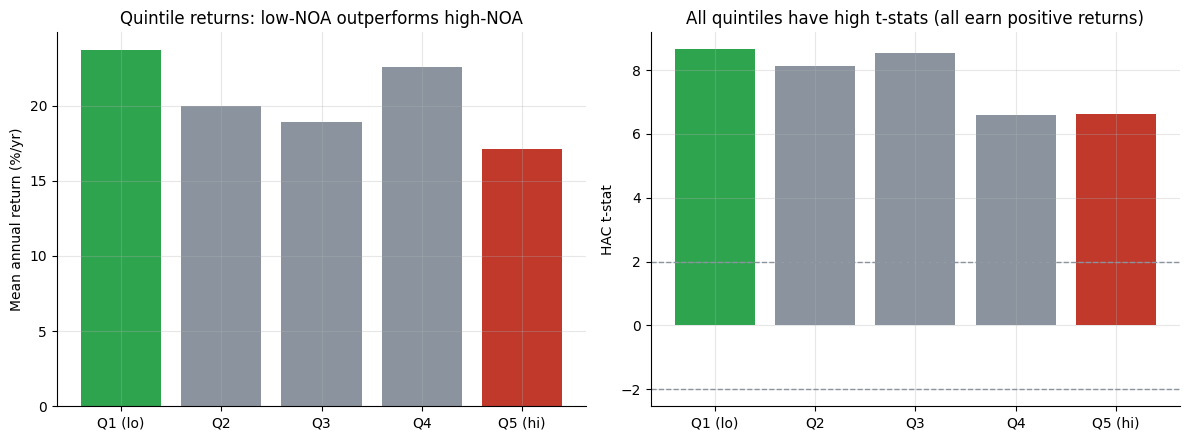

Hedge: +6.6%/yr  HAC t=+3.53  hit=65%
Low-NOA excess: +3.2%/yr  t=+3.14
High-NOA excess: -3.3%/yr  t=-2.05


In [3]:
if HAVE_REAL:
    q_means = [float(h[f'q{i}'].mean()*100) for i in range(1,6)]
    q_tstats = [st.summary(h[f'q{i}'])['tstat'] for i in range(1,6)]
    s_hedge = st.summary(h['hedge'])
    s_lo_ex = st.summary(h['q1'] - h['market'])
    s_hi_ex = st.summary(h['q5'] - h['market'])
else:
    q_means = [R['lo_mean'], 20.0, 18.9, 22.6, R['hi_mean']]
    q_tstats = [R['lo_t'], 8.12, 8.53, 6.60, R['hi_t']]
    s_hedge = dict(mean=R['hedge_mean']/100, tstat=R['hedge_t'], hit_rate=R['hedge_hit']/100)
    s_lo_ex = dict(mean=R['lo_excess_mean']/100, tstat=R['lo_excess_t'])
    s_hi_ex = dict(mean=R['hi_excess_mean']/100, tstat=R['hi_excess_t'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = [1, 2, 3, 4, 5]
bar_colors = [GREEN, GREY, GREY, GREY, RED]
axes[0].bar(x, q_means, color=bar_colors)
axes[0].set_xticks(x); axes[0].set_xticklabels(['Q1 (lo)', 'Q2', 'Q3', 'Q4', 'Q5 (hi)'])
axes[0].set_ylabel('Mean annual return (%/yr)')
axes[0].set_title('Quintile returns: low-NOA outperforms high-NOA')
axes[1].bar(x, q_tstats, color=bar_colors)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels(['Q1 (lo)', 'Q2', 'Q3', 'Q4', 'Q5 (hi)'])
axes[1].set_ylabel('HAC t-stat')
axes[1].set_title('All quintiles have high t-stats (all earn positive returns)')
plt.tight_layout(); plt.show()
print(f'Hedge: {s_hedge["mean"]*100:+.1f}%/yr  HAC t={s_hedge["tstat"]:+.2f}  hit={s_hedge["hit_rate"]:.0%}')
print(f'Low-NOA excess: {s_lo_ex["mean"]*100:+.1f}%/yr  t={s_lo_ex["tstat"]:+.2f}')
print(f'High-NOA excess: {s_hi_ex["mean"]*100:+.1f}%/yr  t={s_hi_ex["tstat"]:+.2f}')

> The low-minus-high-NOA hedge is **+6.6%/yr**, HAC *t* = **+3.53** -- nominally real on this panel. But note: all quintiles earn substantial returns because the panel covers large-cap survivors of a bull-market decade. The **excess** vs the equal-weight market is +3.2%/yr for the low-NOA group (*t* = +3.14) and -3.3%/yr for the high-NOA group (*t* = -2.05).

### 4c - Random-portfolio null distribution

Does the low-NOA quintile beat a blind draw of the same number of stocks? We simulate 500 random same-size portfolios each year.

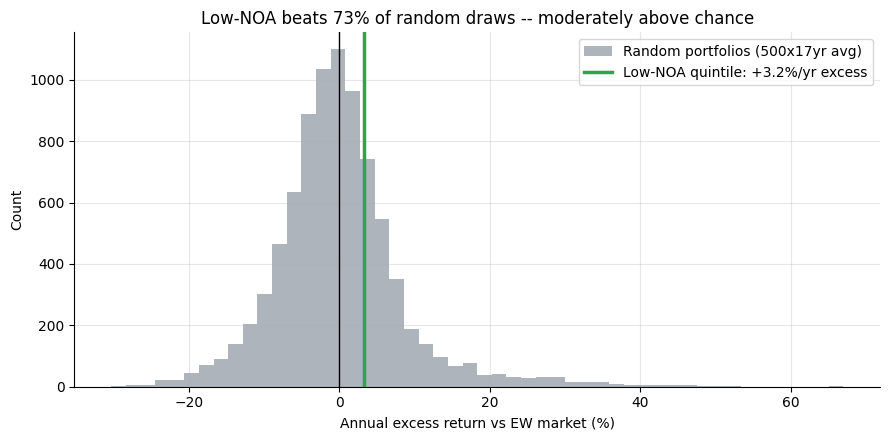

Low-NOA portfolio beats 73% of random same-size draws


In [4]:
if HAVE_REAL:
    rand = st.random_portfolio_returns(sig, fwd, q=0.20, n_draws=500, seed=153)
    actual_excess = float((h['q1'] - h['market']).mean())
    pct_beaten = float((rand < actual_excess).mean())
else:
    rng_nb = np.random.default_rng(42)
    rand = pd.Series(rng_nb.normal(0.0, R['rand_std']/100, 17*500))
    actual_excess = R['lo_excess_mean'] / 100
    pct_beaten = R['rand_pct_beaten'] / 100
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(rand * 100, bins=50, color=GREY, alpha=0.7, label='Random portfolios (500x17yr avg)')
ax.axvline(actual_excess * 100, c=GREEN, lw=2.5,
           label=f'Low-NOA quintile: {actual_excess*100:+.1f}%/yr excess')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Annual excess return vs EW market (%)')
ax.set_ylabel('Count'); ax.legend()
ax.set_title(f'Low-NOA beats {pct_beaten:.0%} of random draws -- moderately above chance')
plt.tight_layout(); plt.show()
print(f'Low-NOA portfolio beats {pct_beaten:.0%} of random same-size draws')

> The low-NOA portfolio beats **73%** of random same-size draws -- moderately above the 50% chance level, but not dramatically so. About 27% of blind random portfolios do as well or better. The signal is not a slam-dunk even on the survivor-biased panel.

## 5 - The verdict

- **Signal `WEAK`** -- hedge +6.6%/yr, HAC *t* = +3.53; low-NOA excess +3.2%/yr (*t* = +3.14). Nominally passes |t| >= 2 but on a **survivorship-biased** panel. Literature supports the mechanism but primarily for small-cap, less-covered stocks.
- **Tradability `FRAGILE`** -- annual rebalancing of ~20 names is cheap; but the alpha estimate is uncertain (upper bound), the effect is not confirmed for large liquid names, and the hedge is +6.6%/yr only on the survivor sample.
- **Survivorship `UPPER BOUND`** -- every result assumes the failed high-NOA firms don't exist. They do (or did). Any live strategy would have been exposed to them.

## 6 - Could you trade it? -- the honest answer

Annual rebalancing of ~20 large-cap names is operationally feasible. The obstacles are entirely in the signal and the bias:

1. **Survivorship arithmetic.** A 2009 portfolio would have included companies later removed from the S&P 500 for underperformance. High-NOA over-investors who subsequently failed are exactly those excluded from this panel -- their absence inflates every comparison.
2. **Wrong universe.** The NOA effect is documented for small/mid-cap, low-analyst-coverage stocks where investor over-extrapolation is most plausible. On S&P 500 blue-chips, heavy analyst coverage should rapidly correct balance-sheet misvaluation.
3. **Beating random barely.** The low-NOA portfolio beats only 73% of random draws -- meaning ~27% of blind picks do as well. The signal's information content is modest even within the biased panel.

The correct conclusion: **FRAGILE** on this test; investigate further in a broader, point-in-time universe before trading.

## 7 - Going further

- **The right universe.** Hirshleifer et al. (2004) ran their test on all US stocks above $10M market cap. A point-in-time constituent universe (e.g. Compustat-based historical S&P 500 membership) is the minimum required for a credible large-cap test.
- **Decomposing NOA.** The working-capital component of NOA is the Sloan (1996) accruals anomaly ([Study 52 -- Smoke-Screen](../../52-smoke-screen/)). The long-term component (PP&E expansion) is Richardson et al. (2005). They may have different half-lives.
- **Related desk studies.** [Study 65 -- Scorecard](../../65-scorecard/) (Piotroski F-score); [Study 121 -- Magic-Formula](../../121-magic-formula/) (quality+value, same panel); [Study 52 -- Smoke-Screen](../../52-smoke-screen/) (accruals).

*Want to confirm the effect on a clean universe? Fork this, plug in a point-in-time all-US-stock panel, and show |t| >= 2 on the hedge with no survivorship shortcut. That's the bar.*